# Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
import missingno as msno
import os
import glob
import json
import yfinance as yf

# I. Loading Data

In [4]:
# Directory where your CSV files are located
base_dir = '/home/hachani/Documents/Cours/UE/IA_717 (Natural Language Processing)/NLP_Project/StockTwits-from-2008-to-2022/data'

folders = {"feature_wo_messages" : "feature_wo_messages/feature_wo_messages_", 
            "messages" : "messages/msg_", 
            "msg_info" : "msg_info/msg_info_",
            "sentiments" : "sentiments/sentiment_",
            "symbols" : "symbols/symbol_",
            "symbol_sentiments" : "symbol_sentiments/symbol_sentiments_"
            }

# directory = os.path.join(base_dir, folders["feature_wo_messages"])

def formater_matricule(number, folder):
    if folder in ["feature_wo_messages", "messages", "symbols"]:
        threshold = 999
        d=len(str(threshold))
    elif folder in ["msg_info", "sentiments", "symbol_sentiments"]:
        threshold = 99
        d=len(str(threshold))

    # Vérification si le nombre est supérieur à 999
    if number > threshold:
        raise ValueError(f"Erreur : Le nombre ne doit pas être supérieur à {threshold}.")
    
    
    # Formatage sur 3 chiffres avec des zéros à gauche
    return f"{number:0{d}d}"

def path_to_csv(number, folder):
    directory = os.path.join(base_dir, folders[folder])
    path = directory+formater_matricule(number=number, folder=folder)+".csv"
    return path


# II. Exploratory Data Analysis

## 0. feature_wo_messages

In [3]:
num = 10
folder = list(folders.keys())[0]
matricule = formater_matricule(num, folder)
path = path_to_csv(num, folder)

print("matricule :", matricule)
print("path :", path)

matricule : 010
path : /home/hachani/Documents/Cours/UE/IA_717 (Natural Language Processing)/NLP_Project/StockTwits-from-2008-to-2022/data/feature_wo_messages/feature_wo_messages_010.csv


In [4]:
data = pd.read_csv(path)
print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 2067041 entries, 0 to 2067040
Data columns (total 7 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   message_id              int64  
 1   user_id                 int64  
 2   created_at              str    
 3   sentiment               str    
 4   parent_message_id       float64
 5   in_reply_to_message_id  float64
 6   symbol_list             str    
dtypes: float64(2), int64(2), str(3)
memory usage: 110.4 MB
None


,message_id,user_id,created_at,sentiment,parent_message_id,in_reply_to_message_id,symbol_list
0,119454395,491191,2018-04-10T17:27:38Z,NaN,NaN,NaN,['XXII']
1,119454396,1347266,2018-04-10T17:27:38Z,NaN,119454396.0,NaN,['NVCN']
2,119454397,1046114,2018-04-10T17:27:39Z,NaN,119448307.0,119448307.0,[]
3,119454398,1088485,2018-04-10T17:27:39Z,Bullish,119454398.0,NaN,['NVCN']
4,119454399,1019697,2018-04-10T17:27:39Z,NaN,119450830.0,119450830.0,[]


In [5]:
data["message_id"] = data["message_id"].astype("category")
data["user_id"] = data["message_id"].astype("category")
data["parent_message_id"] = data["parent_message_id"].astype("Int64").astype("category")
data["in_reply_to_message_id"] = data["in_reply_to_message_id"].astype("Int64").astype("category")
# data["education"] = pd.Categorical(data["education"], ordered=True)

print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 2067041 entries, 0 to 2067040
Data columns (total 7 columns):
 #   Column                  Dtype   
---  ------                  -----   
 0   message_id              category
 1   user_id                 category
 2   created_at              str     
 3   sentiment               str     
 4   parent_message_id       category
 5   in_reply_to_message_id  category
 6   symbol_list             str     
dtypes: category(4), str(3)
memory usage: 117.7 MB
None


,message_id,user_id,created_at,sentiment,parent_message_id,in_reply_to_message_id,symbol_list
0,119454395,119454395,2018-04-10T17:27:38Z,NaN,NaN,NaN,['XXII']
1,119454396,119454396,2018-04-10T17:27:38Z,NaN,119454396,NaN,['NVCN']
2,119454397,119454397,2018-04-10T17:27:39Z,NaN,119448307,119448307,[]
3,119454398,119454398,2018-04-10T17:27:39Z,Bullish,119454398,NaN,['NVCN']
4,119454399,119454399,2018-04-10T17:27:39Z,NaN,119450830,119450830,[]


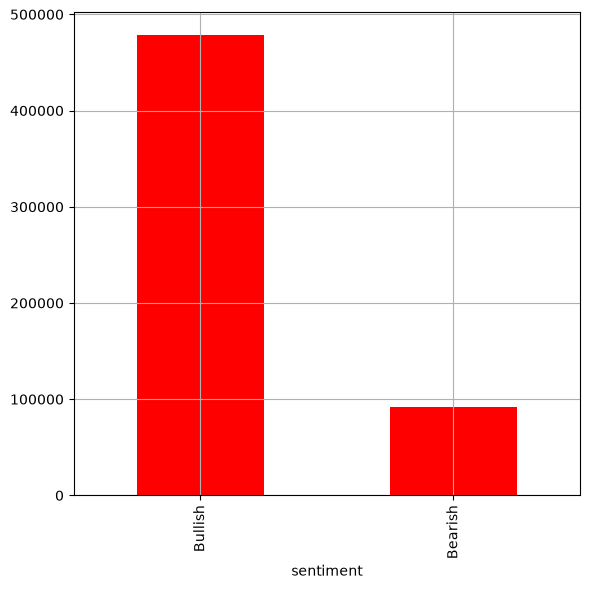

In [6]:
fig, ax1 = plt.subplots(1, 1, figsize=(6,6))
data["sentiment"].value_counts().plot(kind="bar", grid=True, color='r', ax=ax1)
plt.tight_layout()
plt.show()

message_id                 0.000000
user_id                    0.000000
created_at                 0.000000
sentiment                 72.418786
parent_message_id         48.861585
in_reply_to_message_id    61.102465
symbol_list                0.000000
dtype: float64


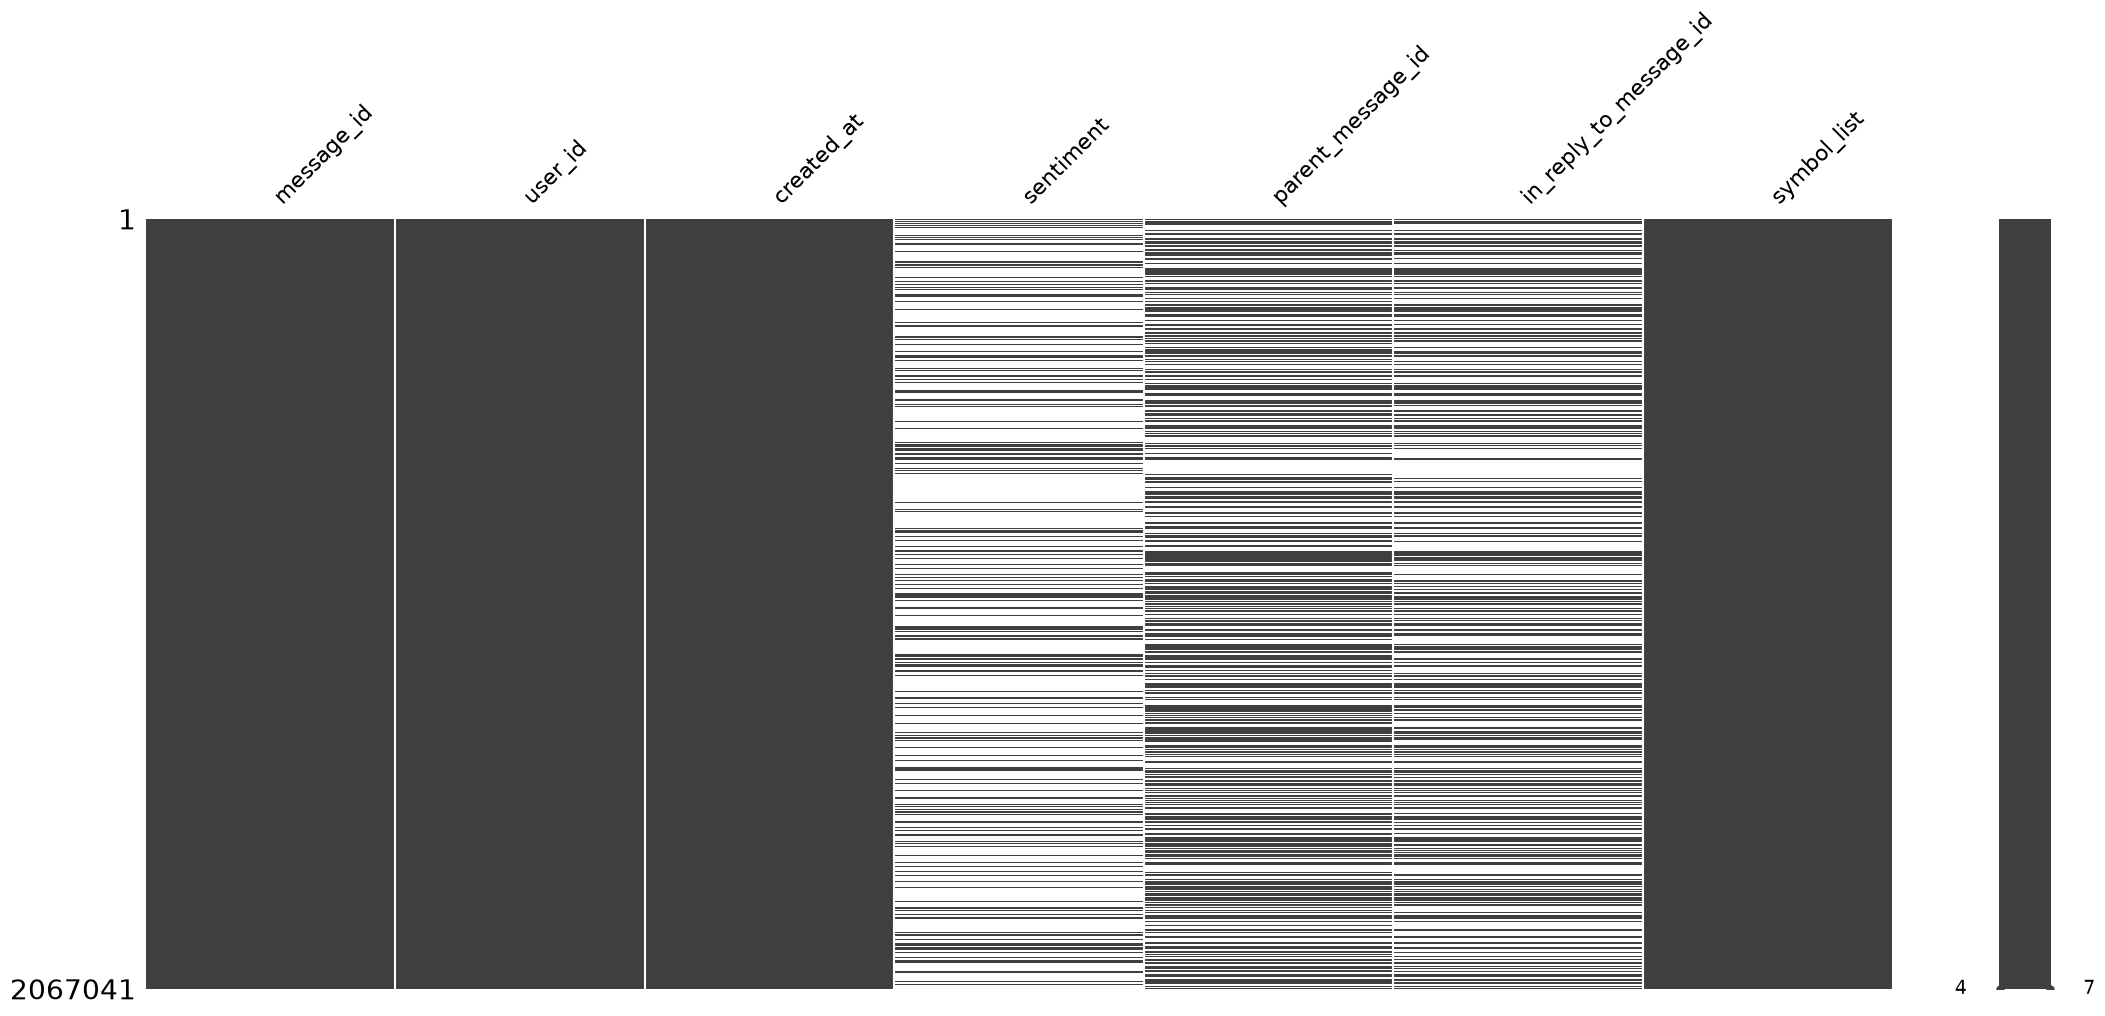

In [7]:
print(data.isna().mean()*100)
msno.matrix(data)
plt.show()

In [8]:
data.describe()

,message_id,user_id,created_at,sentiment,parent_message_id,in_reply_to_message_id,symbol_list
count,2067041,2067041,2067041,570115,1057052,804028,2067041
unique,2067041,2067041,997437,2,257238,598564,48702
top,12001,12001,2018-04-16T14:00:03Z,Bullish,120697196,120632859,[]
freq,1,1,96,478083,693,45,926491


## 1. messages

In [9]:
num = 10
folder = list(folders.keys())[1]
print(folder)
matricule = formater_matricule(num, folder)
path = path_to_csv(num, folder)

print("matricule :", matricule)
print("path :", path)

messages
matricule : 010
path : /home/hachani/Documents/Cours/UE/IA_717 (Natural Language Processing)/NLP_Project/StockTwits-from-2008-to-2022/data/messages/msg_010.csv


In [10]:
data = pd.read_csv(path)
print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 2990463 entries, 0 to 2990462
Data columns (total 2 columns):
 #   Column        Dtype
---  ------        -----
 0   message_id    int64
 1   message_body  str  
dtypes: int64(1), str(1)
memory usage: 45.6 MB
None


,message_id,message_body
0,128168000,"$GBTC Tempted to grab some at the close, but m..."
1,128168001,$TSLA Wait until these production numbers come...
2,128168002,$IBIO one of the best day for iBIO since 2 wee...
3,128168003,@digitalbobby
4,128168004,$NKTR tough close losers. I am so fing happy


In [13]:
data["message_id"] = data["message_id"].astype("category")
data["message_length"] = data["message_body"].dropna().astype(str).str.len()

print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 2990463 entries, 0 to 2990462
Data columns (total 3 columns):
 #   Column          Dtype   
---  ------          -----   
 0   message_id      category
 1   message_body    str     
 2   message_length  int64   
dtypes: category(1), int64(1), str(1)
memory usage: 79.9 MB
None


,message_id,message_body,message_length
0,128168000,"$GBTC Tempted to grab some at the close, but m...",117
1,128168001,$TSLA Wait until these production numbers come...,80
2,128168002,$IBIO one of the best day for iBIO since 2 wee...,108
3,128168003,@digitalbobby,13
4,128168004,$NKTR tough close losers. I am so fing happy,45


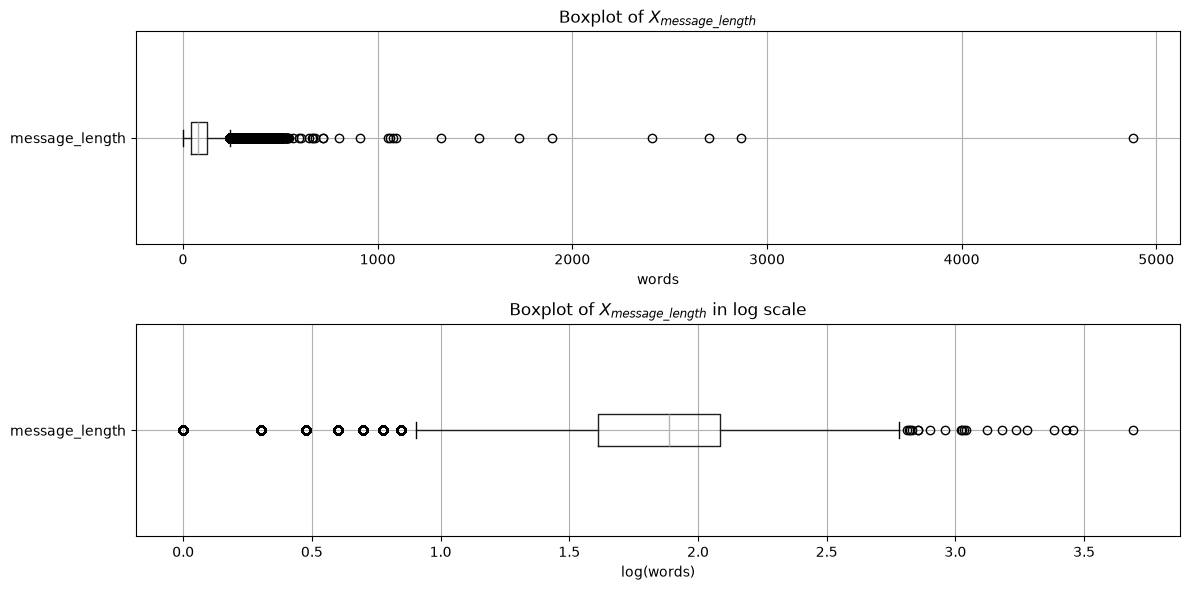

In [22]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
data.boxplot(column="message_length", vert=False, ax=ax1)
np.log10(data[["message_length"]]).boxplot(column="message_length", vert=False, ax=ax2)
ax1.set_title(r"Boxplot of $X_{message\_length}$")
ax1.set_xlabel("words") 
ax2.set_title(r"Boxplot of $X_{message\_length}$ in log scale")
ax2.set_xlabel("log(words)") 
plt.tight_layout()
plt.show()

message_id      0.0
message_body    0.0
dtype: float64


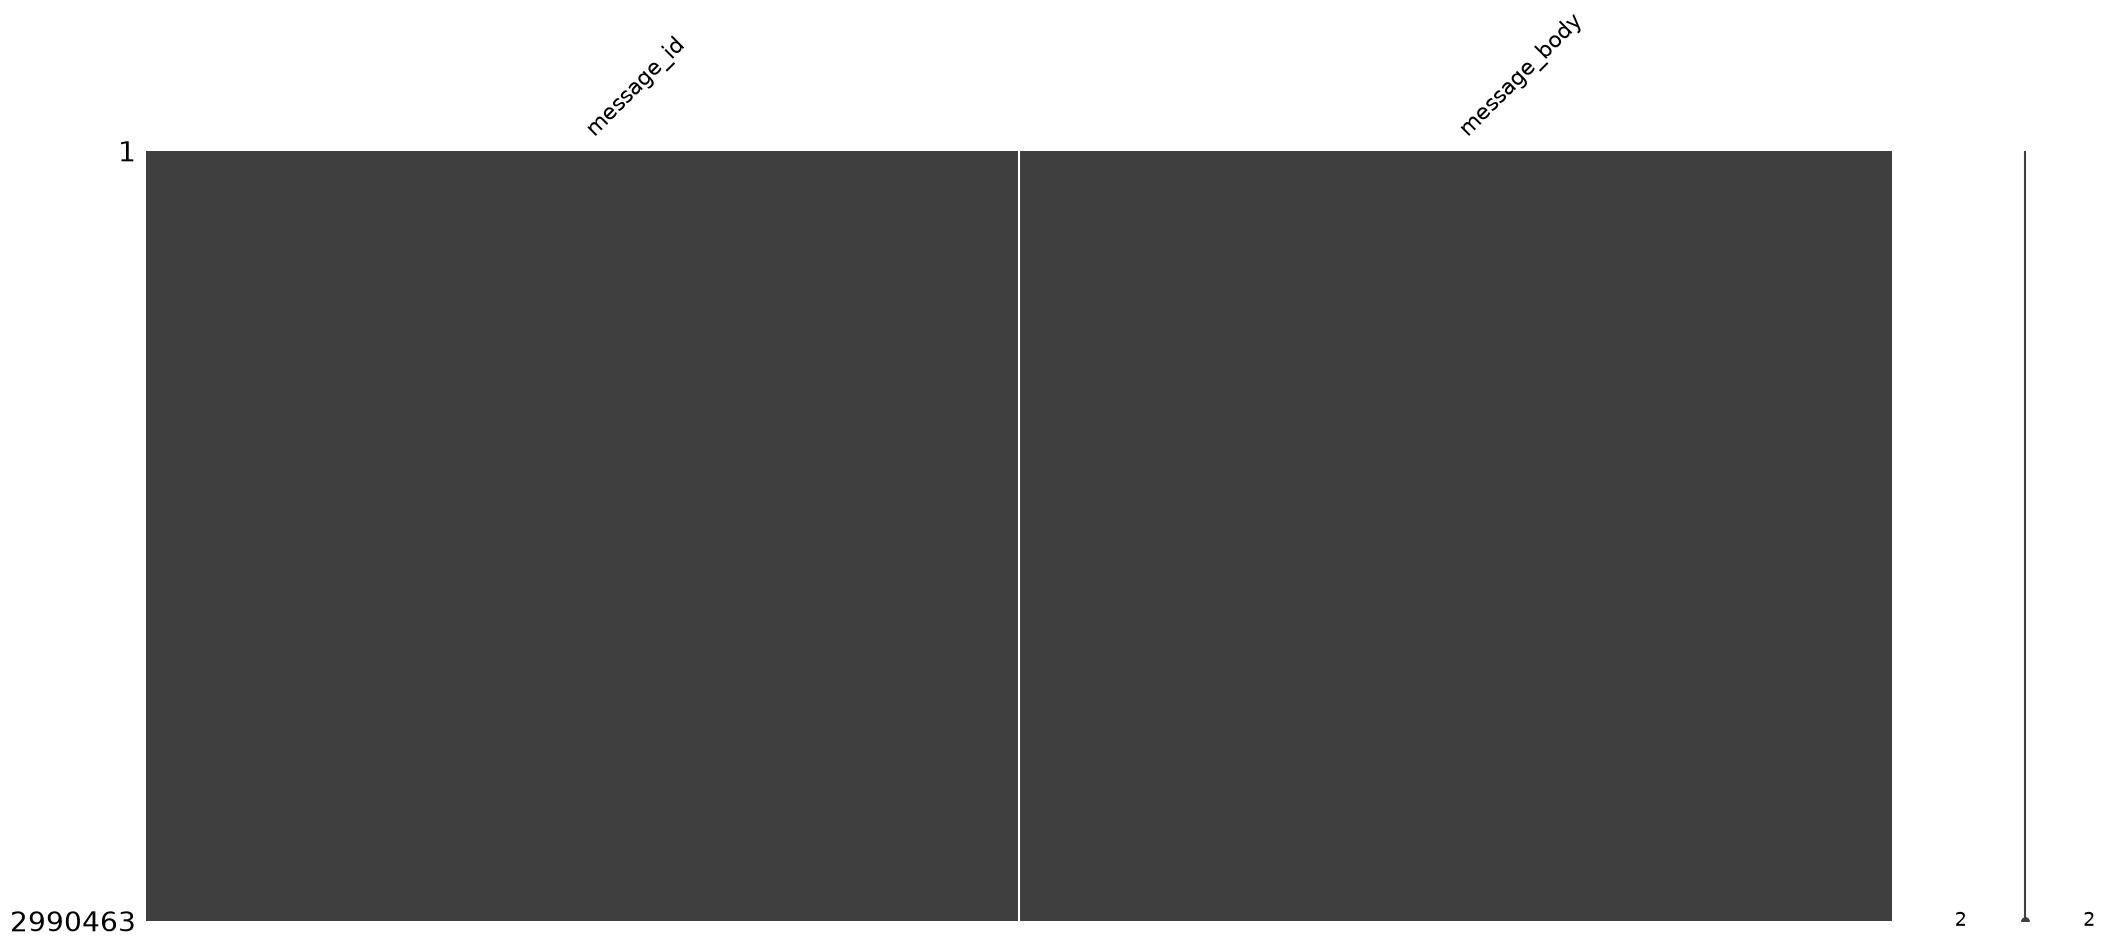

In [12]:
print(data.isna().mean()*100)
msno.matrix(data)
plt.show()

In [25]:
data.describe(include=["category", "str"])

,message_id,message_body
count,2990463,2990463
unique,2990463,2895842
top,13001,$AKER
freq,1,1497


In [18]:
data.describe()

,message_length
count,2.990463e+06
mean,8.317770e+01
std,5.131973e+01
min,1.000000e+00
25%,4.100000e+01
50%,7.700000e+01
75%,1.220000e+02
max,4.878000e+03


## 2. msg_info

In [3]:
num = 10
folder = list(folders.keys())[2]
print(folder)
matricule = formater_matricule(num, folder)
path = path_to_csv(num, folder)

print("matricule :", matricule)
print("path :", path)

msg_info
matricule : 10
path : /home/hachani/Documents/Cours/UE/IA_717 (Natural Language Processing)/NLP_Project/StockTwits-from-2008-to-2022/data/msg_info/msg_info_10.csv


In [4]:
data = pd.read_csv(path)
print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 4993694 entries, 0 to 4993693
Data columns (total 3 columns):
 #   Column           Dtype
---  ------           -----
 0   message_id       int64
 1   length           int64
 2   important_words  str  
dtypes: int64(2), str(1)
memory usage: 114.3 MB
None


,message_id,length,important_words
0,147418451,29,"['nuts', 'theroz_isback', 'muh']"
1,147418452,54,"['relentless', 'impressed', 'actually']"
2,147418453,55,"['41', 'vive', '91']"
3,147418454,22,"['ago', 'long', 'spy']"
4,147418455,133,"['us', 'equipments', 'network']"


In [5]:
data["message_id"] = data["message_id"].astype("category")

print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 4993694 entries, 0 to 4993693
Data columns (total 3 columns):
 #   Column           Dtype   
---  ------           -----   
 0   message_id       category
 1   length           int64   
 2   important_words  str     
dtypes: category(1), int64(1), str(1)
memory usage: 133.3 MB
None


,message_id,length,important_words
0,147418451,29,"['nuts', 'theroz_isback', 'muh']"
1,147418452,54,"['relentless', 'impressed', 'actually']"
2,147418453,55,"['41', 'vive', '91']"
3,147418454,22,"['ago', 'long', 'spy']"
4,147418455,133,"['us', 'equipments', 'network']"


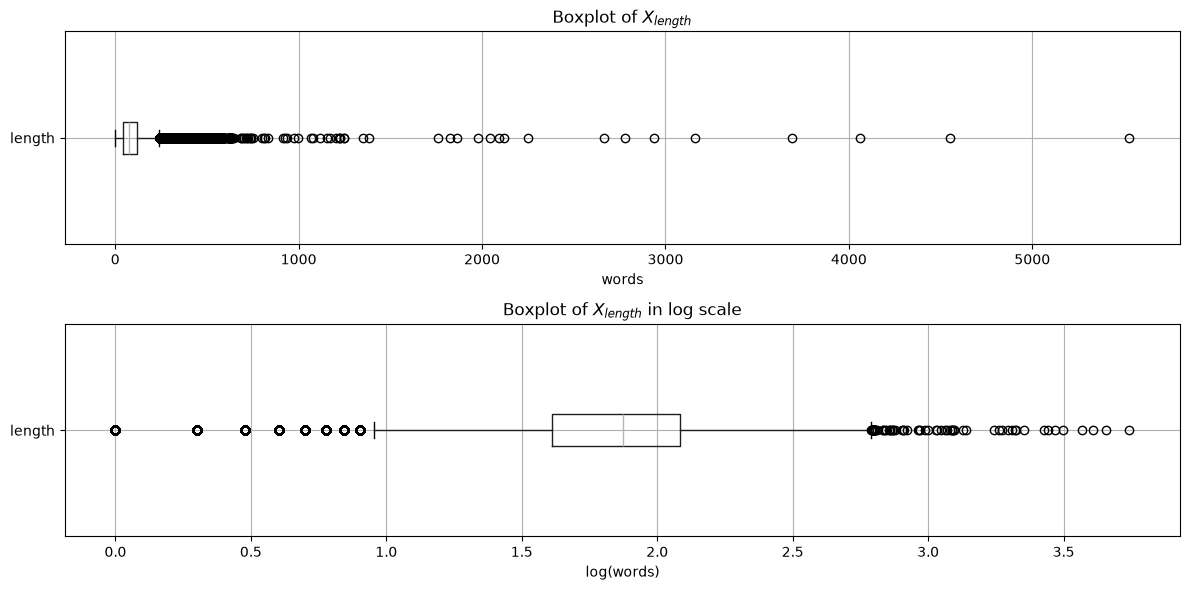

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))
data.boxplot(column="length", vert=False, ax=ax1)
np.log10(data[["length"]]).boxplot(column="length", vert=False, ax=ax2)
ax1.set_title(r"Boxplot of $X_{length}$")
ax1.set_xlabel("words") 
ax2.set_title(r"Boxplot of $X_{length}$ in log scale")
ax2.set_xlabel("log(words)") 
plt.tight_layout()
plt.show()

message_id         0.0
length             0.0
important_words    0.0
dtype: float64


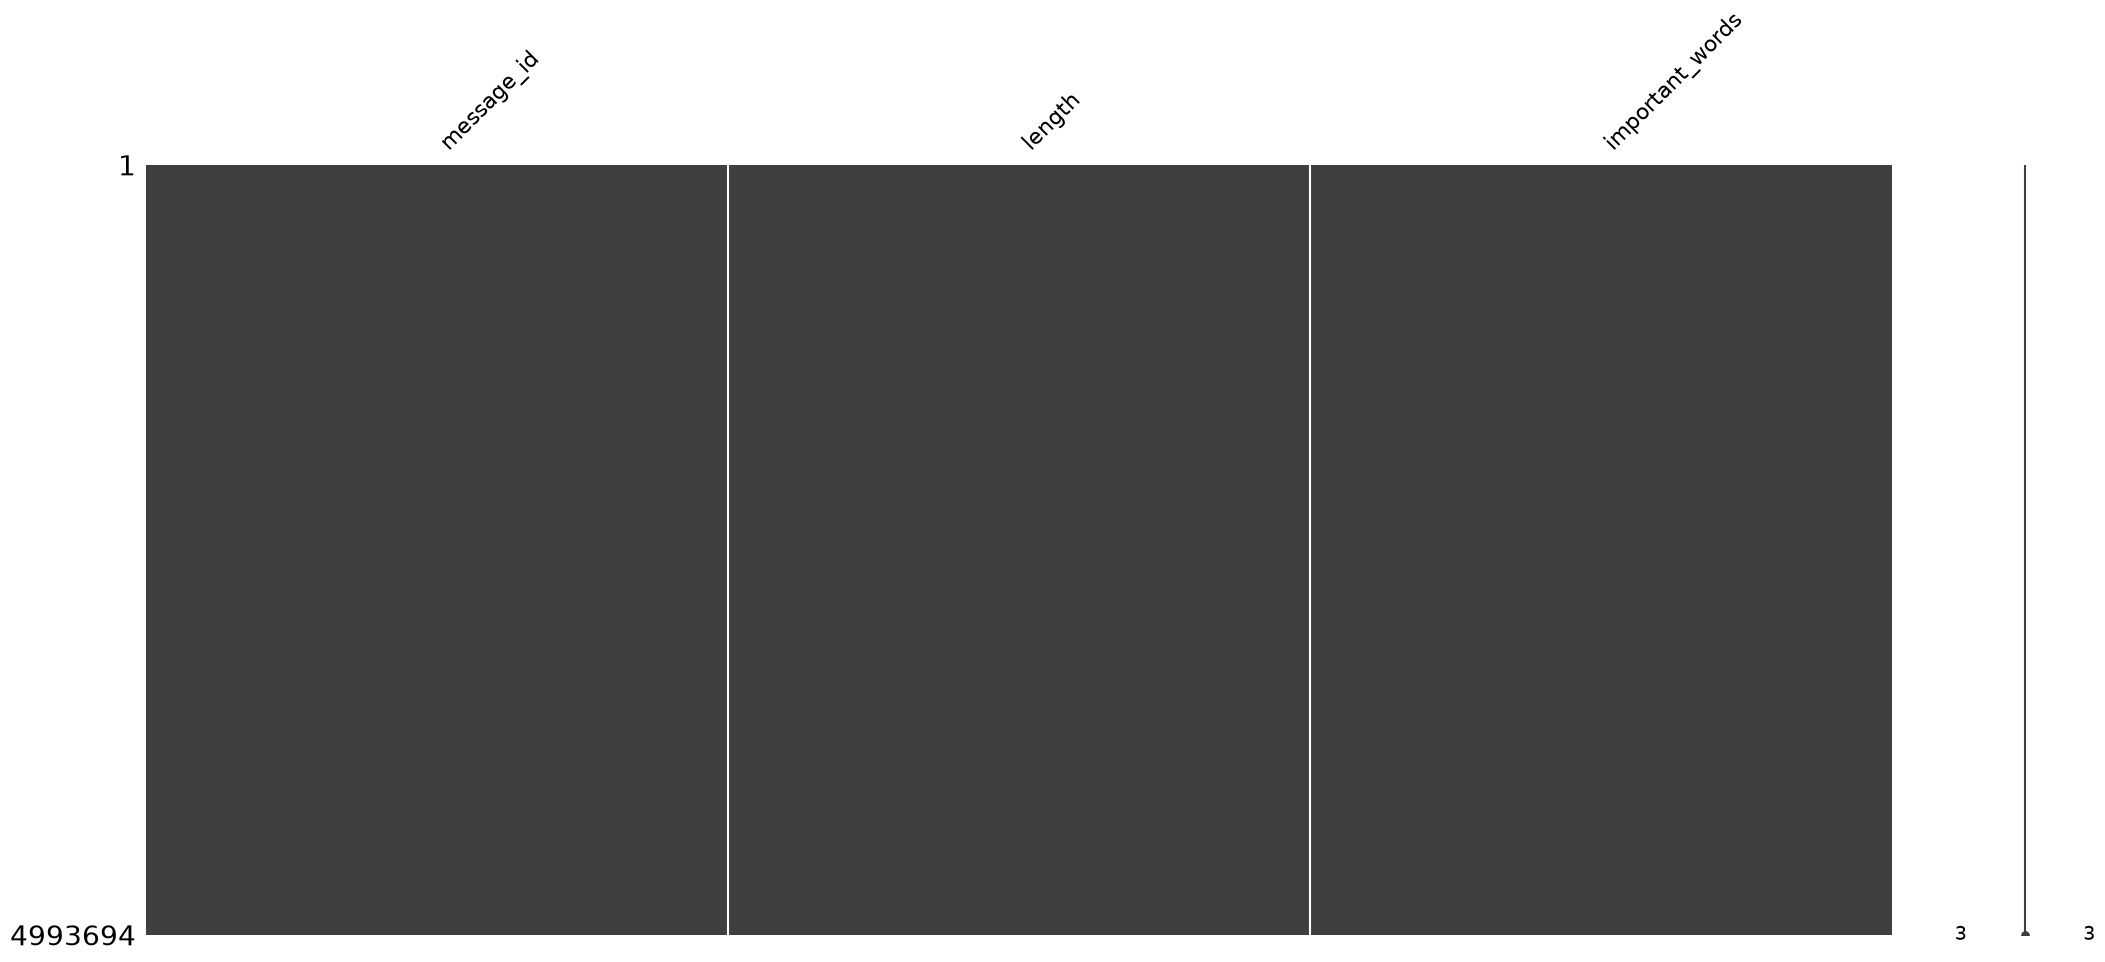

In [6]:
print(data.isna().mean()*100)
msno.matrix(data)
plt.show()

In [7]:
data.describe(include=["category", "str"])

,message_id,important_words
count,4993694,4993694
unique,4993694,4662676
top,15006,['spy']
freq,1,4129


In [8]:
data.describe()

,length
count,4.993694e+06
mean,8.207439e+01
std,5.105235e+01
min,1.000000e+00
25%,4.100000e+01
50%,7.500000e+01
75%,1.210000e+02
max,5.529000e+03


## 3. sentiments

In [10]:
num = 10
folder = list(folders.keys())[3]
print(folder)
matricule = formater_matricule(num, folder)
path = path_to_csv(num, folder)

print("matricule :", matricule)
print("path :", path)

sentiments
matricule : 10
path : /home/hachani/Documents/Cours/UE/IA_717 (Natural Language Processing)/NLP_Project/StockTwits-from-2008-to-2022/data/sentiments/sentiment_10.csv


In [11]:
data = pd.read_csv(path)
print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 2732270 entries, 0 to 2732269
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   message_id   int64  
 1   user_id      int64  
 2   created_at   str    
 3   sentiment    float64
 4   symbol_list  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 104.2 MB
None


,message_id,user_id,created_at,sentiment,symbol_list
0,187567380,775713,2019-12-19,-1.0,['BB']
1,187567384,2927120,2019-12-19,1.0,['VSTM']
2,187567393,1606911,2019-12-19,1.0,[]
3,187567395,1171441,2019-12-19,-1.0,['MOMO']
4,187567400,1631915,2019-12-19,1.0,['INPX']


In [12]:
data["message_id"] = data["message_id"].astype("category")
data["user_id"] = data["user_id"].astype("category")

print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 2732270 entries, 0 to 2732269
Data columns (total 5 columns):
 #   Column       Dtype   
---  ------       -----   
 0   message_id   category
 1   user_id      category
 2   created_at   str     
 3   sentiment    float64 
 4   symbol_list  str     
dtypes: category(2), float64(1), str(2)
memory usage: 104.8 MB
None


,message_id,user_id,created_at,sentiment,symbol_list
0,187567380,775713,2019-12-19,-1.0,['BB']
1,187567384,2927120,2019-12-19,1.0,['VSTM']
2,187567393,1606911,2019-12-19,1.0,[]
3,187567395,1171441,2019-12-19,-1.0,['MOMO']
4,187567400,1631915,2019-12-19,1.0,['INPX']


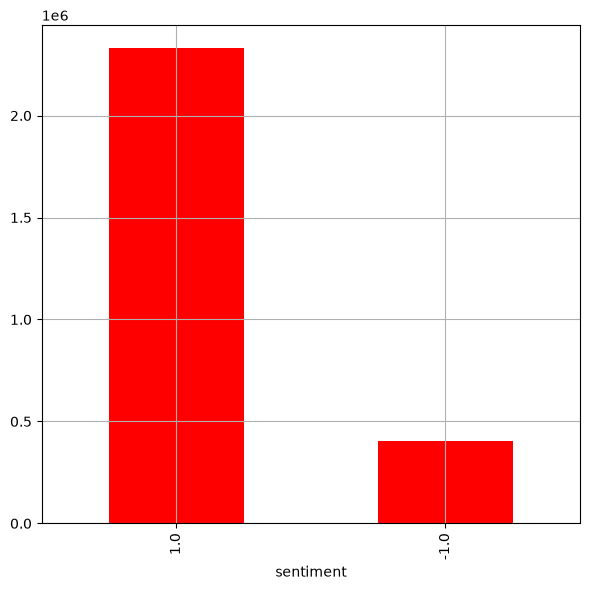

In [13]:
fig, ax1 = plt.subplots(1, 1, figsize=(6,6))
data["sentiment"].value_counts().plot(kind="bar", grid=True, color='r', ax=ax1)
plt.tight_layout()
plt.show()

message_id     0.0
user_id        0.0
created_at     0.0
sentiment      0.0
symbol_list    0.0
dtype: float64


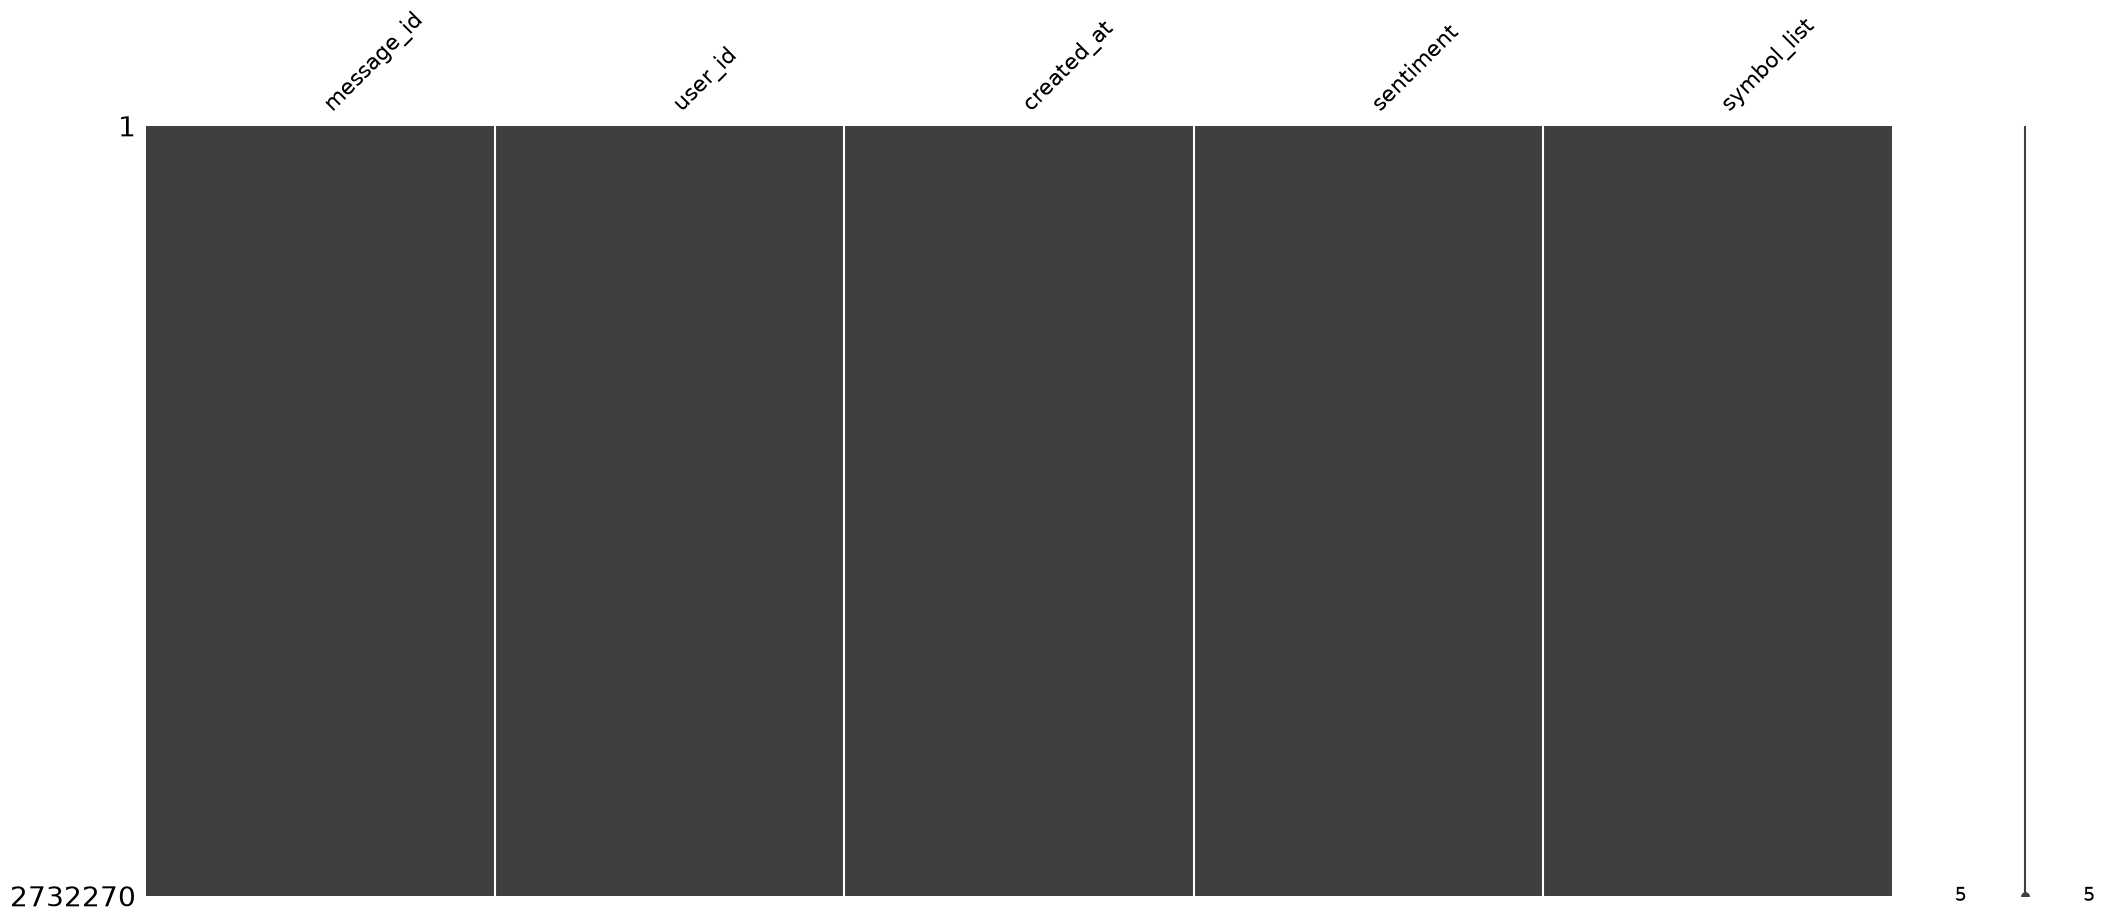

In [14]:
print(data.isna().mean()*100)
msno.matrix(data)
plt.show()

In [15]:
data.describe(include=["category", "str"])

,message_id,user_id,created_at,symbol_list
count,2732270,2732270,2732270,2732270
unique,2732270,75261,106,59285
top,1876023,1245096,2020-02-13,[]
freq,1,14382,74455,934915


In [16]:
data.describe()

,sentiment
count,2.732270e+06
mean,7.048637e-01
std,7.093429e-01
min,-1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00


## 4. symbols

In [17]:
num = 10
folder = list(folders.keys())[4]
print(folder)
matricule = formater_matricule(num, folder)
path = path_to_csv(num, folder)

print("matricule :", matricule)
print("path :", path)

symbols
matricule : 010
path : /home/hachani/Documents/Cours/UE/IA_717 (Natural Language Processing)/NLP_Project/StockTwits-from-2008-to-2022/data/symbols/symbol_010.csv


In [18]:
data = pd.read_csv(path)
print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 1763375 entries, 0 to 1763374
Data columns (total 7 columns):
 #   Column       Dtype  
---  ------       -----  
 0   message_id   int64  
 1   user_id      int64  
 2   created_at   str    
 3   sentiment    float64
 4   symbol_list  str    
 5   sym_number   int64  
 6   symbol       str    
dtypes: float64(1), int64(3), str(3)
memory usage: 94.2 MB
None


,message_id,user_id,created_at,sentiment,symbol_list,sym_number,symbol
0,131292195,1309213,2018-07-25,NaN,"['BTC.X', 'ETH.X', 'ICN.X', 'XNO.X']",4,BTC.X
1,131292196,1534555,2018-07-25,NaN,['HMNY'],1,HMNY
2,131292197,261201,2018-07-25,1.0,['AMZN'],1,AMZN
3,131292198,180213,2018-07-25,-1.0,['HMNY'],1,HMNY
4,131292200,1245280,2018-07-25,NaN,['ATTU'],1,ATTU


In [19]:
data["message_id"] = data["message_id"].astype("category")
data["user_id"] = data["user_id"].astype("category")

print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 1763375 entries, 0 to 1763374
Data columns (total 7 columns):
 #   Column       Dtype   
---  ------       -----   
 0   message_id   category
 1   user_id      category
 2   created_at   str     
 3   sentiment    float64 
 4   symbol_list  str     
 5   sym_number   int64   
 6   symbol       str     
dtypes: category(2), float64(1), int64(1), str(3)
memory usage: 94.6 MB
None


,message_id,user_id,created_at,sentiment,symbol_list,sym_number,symbol
0,131292195,1309213,2018-07-25,NaN,"['BTC.X', 'ETH.X', 'ICN.X', 'XNO.X']",4,BTC.X
1,131292196,1534555,2018-07-25,NaN,['HMNY'],1,HMNY
2,131292197,261201,2018-07-25,1.0,['AMZN'],1,AMZN
3,131292198,180213,2018-07-25,-1.0,['HMNY'],1,HMNY
4,131292200,1245280,2018-07-25,NaN,['ATTU'],1,ATTU


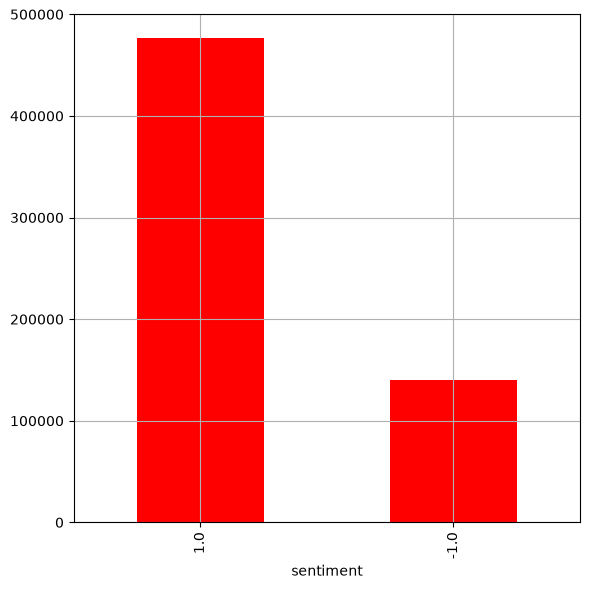

In [23]:
fig, ax1 = plt.subplots(1, 1, figsize=(6,6))
data["sentiment"].value_counts().plot(kind="bar", grid=True, color='r', ax=ax1)
plt.tight_layout()
plt.show()

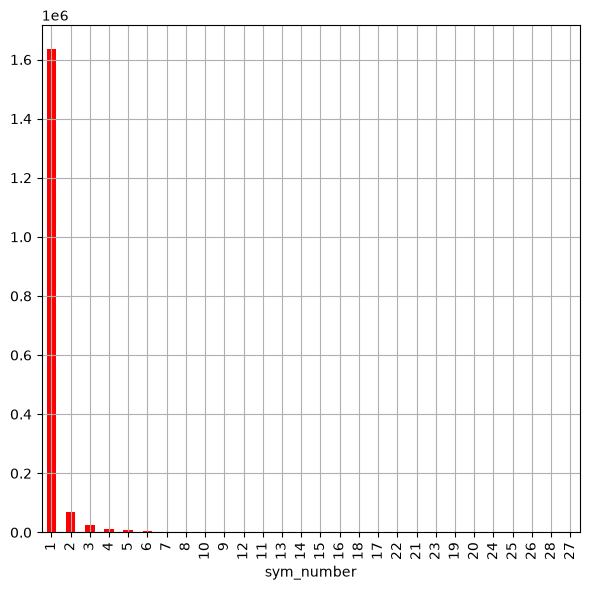

In [25]:
fig, ax1 = plt.subplots(1, 1, figsize=(6,6))
data["sym_number"].value_counts().plot(kind="bar", grid=True, color='r', ax=ax1)
plt.tight_layout()
plt.show()

message_id      0.000000
user_id         0.000000
created_at      0.000000
sentiment      64.999277
symbol_list     0.000000
sym_number      0.000000
symbol          0.000000
dtype: float64


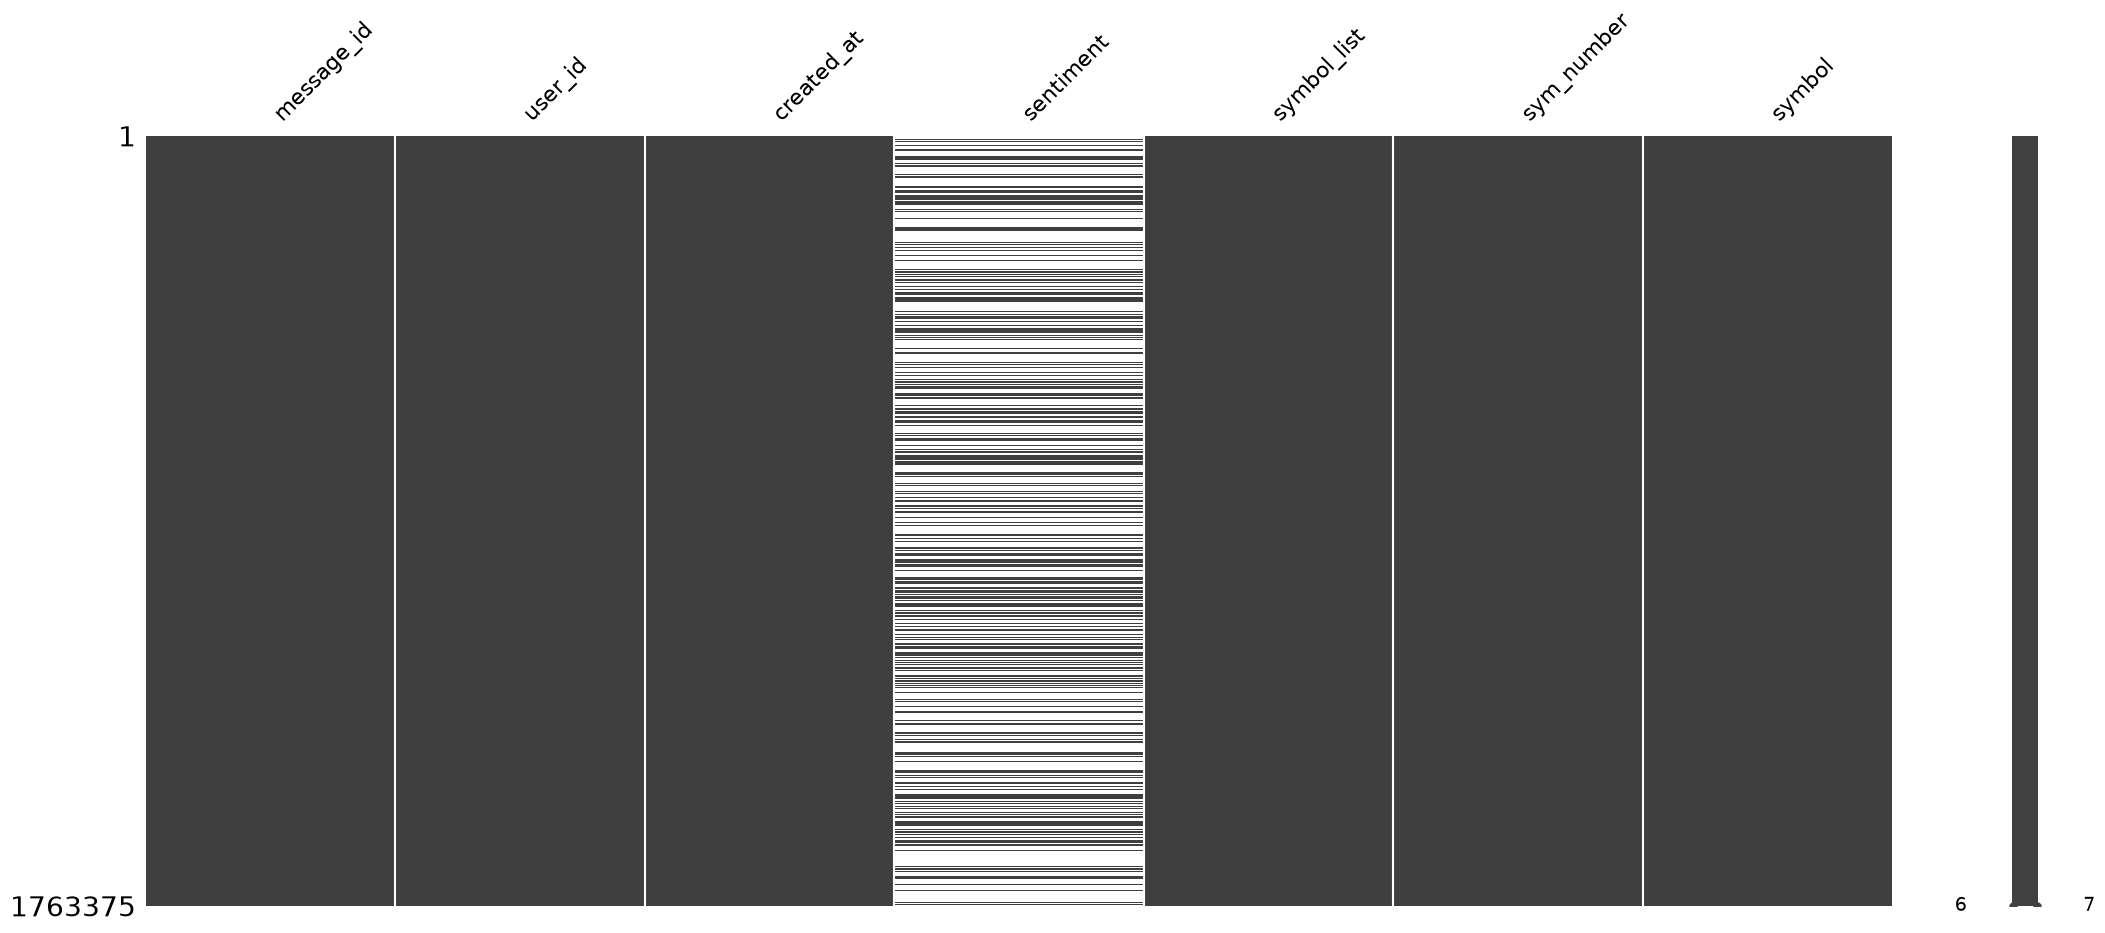

In [20]:
print(data.isna().mean()*100)
msno.matrix(data)
plt.show()

In [21]:
data.describe(include=["category", "str"])

,message_id,user_id,created_at,symbol_list,symbol
count,1763375,1763375,1763375,1763375,1763375
unique,1763375,61336,58,61141,9321
top,132000,727510,2018-07-26,['HMNY'],HMNY
freq,1,33824,94345,113851,116182


In [22]:
data.describe()

,sentiment,sym_number
count,617194.000000,1.763375e+06
mean,0.544545,1.183555e+00
std,0.838732,1.024512e+00
min,-1.000000,1.000000e+00
25%,1.000000,1.000000e+00
50%,1.000000,1.000000e+00
75%,1.000000,1.000000e+00
max,1.000000,2.800000e+01


## 5. symbol_sentiments

In [5]:
num = 10
folder = list(folders.keys())[5]
print(folder)
matricule = formater_matricule(num, folder)
path = path_to_csv(num, folder)

print("matricule :", matricule)
print("path :", path)

symbol_sentiments
matricule : 10
path : /home/hachani/Documents/Cours/UE/IA_717 (Natural Language Processing)/NLP_Project/StockTwits-from-2008-to-2022/data/symbol_sentiments/symbol_sentiments_10.csv


In [6]:
data = pd.read_csv(path)
print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 3172230 entries, 0 to 3172229
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   message_id   int64  
 1   user_id      int64  
 2   created_at   str    
 3   sentiment    float64
 4   symbol_list  str    
dtypes: float64(1), int64(2), str(2)
memory usage: 121.0 MB
None


,message_id,user_id,created_at,sentiment,symbol_list
0,251425281,4022770,2020-10-20,1.0,['LGMK']
1,251425284,4152575,2020-10-20,1.0,['LYL']
2,251425292,468895,2020-10-20,1.0,['NVAX']
3,251425296,801130,2020-10-20,1.0,['SPY']
4,251425299,4099471,2020-10-20,1.0,['SNDL']


In [7]:
data["message_id"] = data["message_id"].astype("category")
data["user_id"] = data["user_id"].astype("category")

print(data.info())
data.head()

<class 'pandas.DataFrame'>
RangeIndex: 3172230 entries, 0 to 3172229
Data columns (total 5 columns):
 #   Column       Dtype   
---  ------       -----   
 0   message_id   category
 1   user_id      category
 2   created_at   str     
 3   sentiment    float64 
 4   symbol_list  str     
dtypes: category(2), float64(1), str(2)
memory usage: 122.1 MB
None


,message_id,user_id,created_at,sentiment,symbol_list
0,251425281,4022770,2020-10-20,1.0,['LGMK']
1,251425284,4152575,2020-10-20,1.0,['LYL']
2,251425292,468895,2020-10-20,1.0,['NVAX']
3,251425296,801130,2020-10-20,1.0,['SPY']
4,251425299,4099471,2020-10-20,1.0,['SNDL']


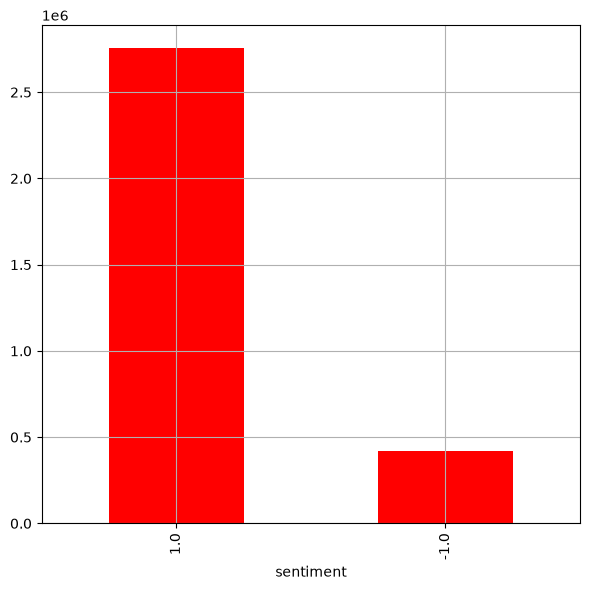

In [8]:
fig, ax1 = plt.subplots(1, 1, figsize=(6,6))
data["sentiment"].value_counts().plot(kind="bar", grid=True, color='r', ax=ax1)
plt.tight_layout()
plt.show()

message_id     0.0
user_id        0.0
created_at     0.0
sentiment      0.0
symbol_list    0.0
dtype: float64


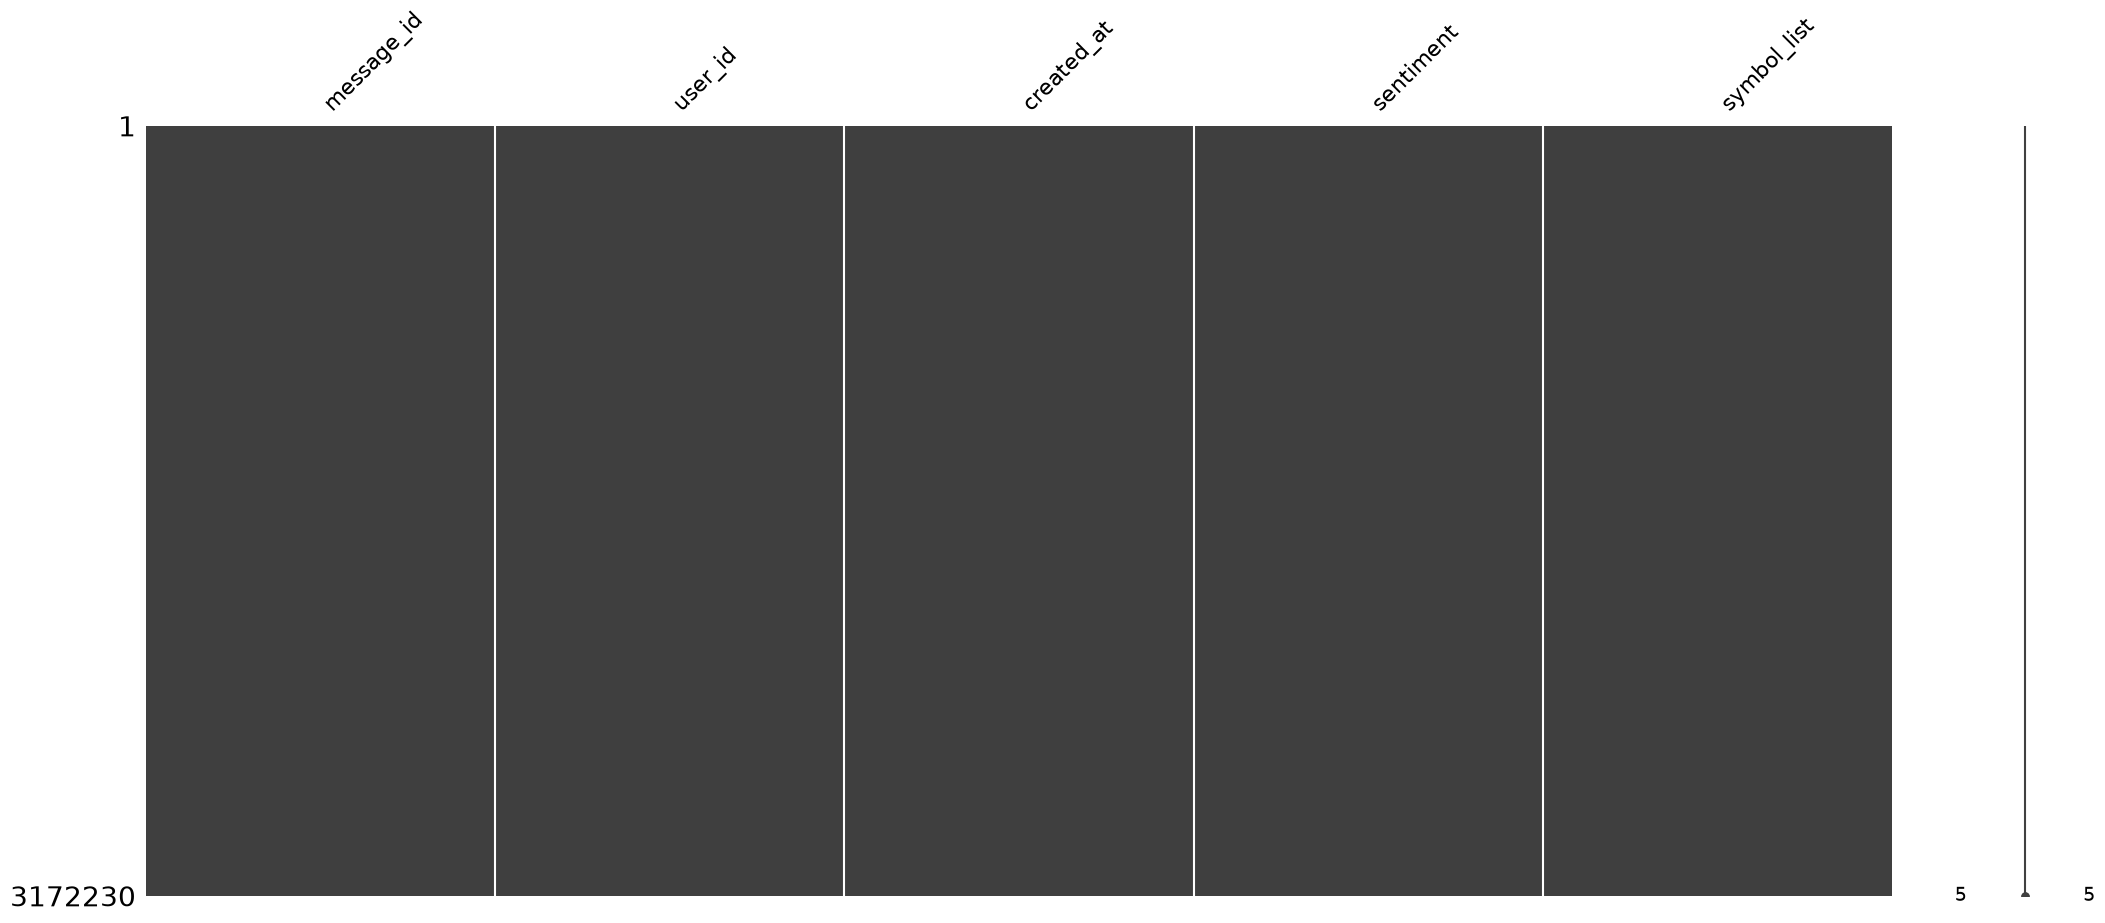

In [9]:
print(data.isna().mean()*100)
msno.matrix(data)
plt.show()

In [10]:
data.describe(include=["category", "str"])

,message_id,user_id,created_at,symbol_list
count,3172230,3172230,3172230,3172230
unique,3172230,143537,120,117852
top,2515033,967528,2020-12-01,['NIO']
freq,1,13123,90469,112972


In [11]:
data.describe()

,sentiment
count,3.172230e+06
mean,7.360084e-01
std,6.769725e-01
min,-1.000000e+00
25%,1.000000e+00
50%,1.000000e+00
75%,1.000000e+00
max,1.000000e+00
